**# Atividade 3:  RNN-LSTM aplicada na estimativa da de preço de ações no mercado.**

VITOR HUGO DA SILVA SANTOS

RA: 625102765

# Professor para esse primeiro código foi utilizado a função para adicionar e importar as bibliotecas com os arquivos csv da MasterCard, sem a necessidade de colocar o arquivo csv manualemente!


Parte 1: Você é um investidor e gostaria de entender melhor como está a evolução dos preços das ações de algumas empresas, entre elas a MasterCard, para fazer um aporte em novas ações. A evolução do preço dos ativos está registrada em diferentes sites da Internet e há dados históricos disponíveis. Montar um código em Python, usando o ambiente Colab, capaz de estimar o preço das ações no ano de 2021.

Iniciando a preparação e treinamento do modelo LSTM para ações da Mastercard (via Kagglehub)...
Carregando dataset do Kaggle: kalilurrahman/mastercard-stock-data-latest-and-updated


/tmp/ipython-input-894013291.py:24: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'mastercard-stock-data-latest-and-updated' dataset.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinamento do modelo concluído.

--- Resultados da Previsão para 2021 (Kagglehub) ---
Erro Quadrático Médio da Raiz (RMSE): 7.9797
Previsão para o primeiro dia de 2021: $342.72
Previsão para o último dia de 2021: $348.65
Resultados e gráfico salvos com o sufixo '_kagglehub'.


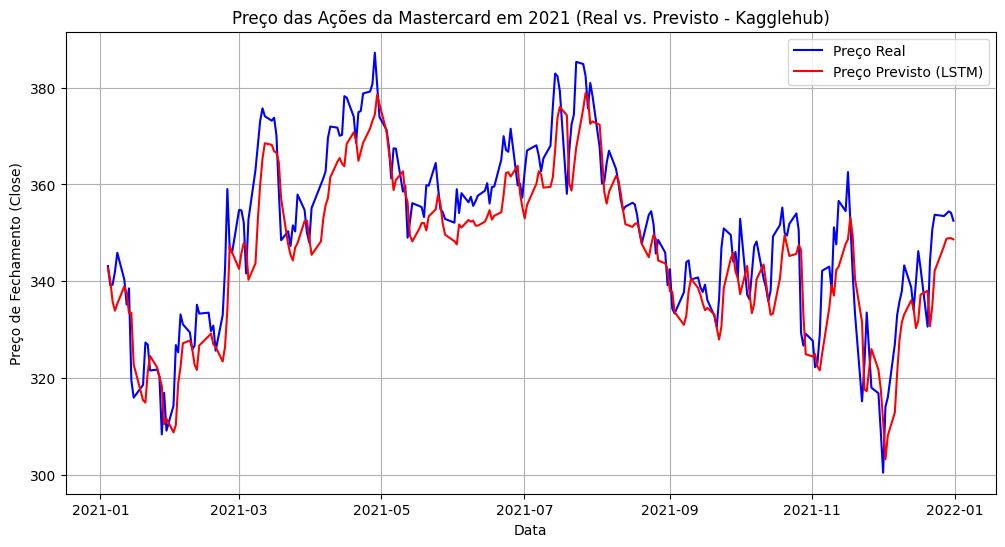

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

# --- Configurações ---
TARGET_COLUMN = 'Close'
TIME_STEP = 60
PREDICTION_YEAR = 2021
DATASET_REF = "kalilurrahman/mastercard-stock-data-latest-and-updated"
FILE_NAME = "Mastercard_stock_history.csv" # Nome do arquivo dentro do dataset do Kaggle

# --- 1. Carregamento e Pré-processamento de Dados ---
def load_and_preprocess_data(target_column, prediction_year):
    print(f"Carregando dataset do Kaggle: {DATASET_REF}")

    # Carregar o dataset usando kagglehub
    # O adapter PANDAS carrega o CSV diretamente em um DataFrame
    df = kagglehub.load_dataset(
      KaggleDatasetAdapter.PANDAS,
      DATASET_REF,
      FILE_NAME,
    )

    # Renomear colunas para consistência (o dataset do Kaggle pode ter nomes diferentes)
    # Assumindo que o nome da coluna de data é 'Date' e o preço de fechamento é 'Close'

    # Conversão e definição do índice de data
    df['Date'] = pd.to_datetime(df['Date'], utc=True)
    df.set_index('Date', inplace=True)

    # Separar dados de treino (antes do ano de previsão) e dados de teste (ano de previsão)
    train_data = df.loc[df.index.year < prediction_year, target_column].values.reshape(-1, 1)

    # Normalizar os dados de treino
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data)

    # Para prever 2021, precisamos dos dados de 2020 para as primeiras janelas de 60 dias.
    start_index_2021 = df.index.get_loc(df.loc[df.index.year == prediction_year].index[0])
    full_test_start_index = start_index_2021 - TIME_STEP

    # Criar o conjunto de dados completo para escalonamento do teste (inclui lookback)
    full_data_for_test_scaling = df[target_column].values.reshape(-1, 1)
    test_input = full_data_for_test_scaling[full_test_start_index:]

    # Escalonar o conjunto de teste (usando o scaler ajustado nos dados de treino)
    test_scaled = scaler.transform(test_input)

    return df, train_scaled, test_scaled, scaler

# --- 2. Criação da Estrutura de Dados (Sequências) ---
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step):
        # x: sequência de 'time_step' valores
        a = dataset[i:(i + time_step), 0]
        dataX.append(a)
        # y: o valor seguinte (o que queremos prever)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

# --- 3. Construção e Treinamento do Modelo LSTM ---
def build_and_train_model(trainX, trainY):
    # Remodelar a entrada para o formato [amostras, time_step, features]
    trainX = trainX.reshape(trainX.shape[0], trainX.shape[1], 1)

    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(TIME_STEP, 1)))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))

    model.compile(loss='mean_squared_error', optimizer='adam')

    # Treinar o modelo
    model.fit(trainX, trainY, validation_split=0.1, epochs=100, batch_size=64, verbose=0)

    return model

# --- 4. Previsão e Pós-processamento ---
def make_predictions(model, test_scaled, scaler, real_2021_len):
    # Criar o dataset de teste (sequências)
    testX, _ = create_dataset(test_scaled, TIME_STEP)

    # Remodelar a entrada para o formato [amostras, time_step, features]
    testX = testX.reshape(testX.shape[0], testX.shape[1], 1)

    # Prever
    test_predict = model.predict(testX, verbose=0)

    # Inverter a normalização para obter os valores de preço reais
    test_predict = scaler.inverse_transform(test_predict)

    # Ajustar o número de previsões para corresponder aos dados reais (252 dias úteis)
    if test_predict.shape[0] > real_2021_len:
        test_predict = test_predict[:real_2021_len]
    elif test_predict.shape[0] != real_2021_len:
        print(f"Aviso: Número de previsões ({test_predict.shape[0]}) não corresponde ao número de dias reais ({real_2021_len}).")

    return test_predict

# --- 5. Execução Principal ---
def main():
    print("Iniciando a preparação e treinamento do modelo LSTM para ações da Mastercard (via Kagglehub)...")

    # 1. Carregar e Pré-processar
    df_full, train_scaled, test_scaled, scaler = load_and_preprocess_data(TARGET_COLUMN, PREDICTION_YEAR)

    # 2. Criar Estrutura de Dados
    trainX, trainY = create_dataset(train_scaled, TIME_STEP)

    # 3. Construir e Treinar o Modelo
    model = build_and_train_model(trainX, trainY)
    print("Treinamento do modelo concluído.")

    # Obter os valores reais de 2021 para comparação
    real_2021 = df_full.loc[df_full.index.year == PREDICTION_YEAR, TARGET_COLUMN].values.reshape(-1, 1)

    # 4. Previsão
    test_predict = make_predictions(model, test_scaled, scaler, len(real_2021))

    # Calcular o RMSE (Root Mean Squared Error) para avaliar a precisão
    rmse = np.sqrt(mean_squared_error(real_2021, test_predict))

    print(f"\n--- Resultados da Previsão para {PREDICTION_YEAR} (Kagglehub) ---")
    print(f"Erro Quadrático Médio da Raiz (RMSE): {rmse:.4f}")
    print(f"Previsão para o primeiro dia de {PREDICTION_YEAR}: ${test_predict[0][0]:.2f}")
    print(f"Previsão para o último dia de {PREDICTION_YEAR}: ${test_predict[-1][0]:.2f}")

    # Criar um DataFrame para a saída final
    dates_2021 = df_full.loc[df_full.index.year == PREDICTION_YEAR].index

    # Garantir que as datas e previsões tenham o mesmo comprimento
    results_df = pd.DataFrame({
        'Date': dates_2021,
        'Real_Price': real_2021.flatten(),
        'Predicted_Price': test_predict.flatten()
    })

    # Salvar o DataFrame de resultados em um arquivo Markdown para apresentação
    results_md = results_df.to_markdown(index=False)
    with open('mastercard_2021_predictions_kagglehub.md', 'w') as f:
        f.write("# Previsão de Preços das Ações da Mastercard (2021) - Modelo LSTM (Kagglehub)\n\n")
        f.write(f"**Fonte de Dados:** {DATASET_REF}\n")
        f.write(f"**Coluna Alvo:** {TARGET_COLUMN}\n")
        f.write(f"**Passo de Tempo (TIME_STEP):** {TIME_STEP} dias\n")
        f.write(f"**RMSE (Root Mean Squared Error):** {rmse:.4f}\n\n")
        f.write("## Tabela de Resultados (Preços Reais vs. Previsões)\n\n")
        f.write(results_md)

    # Geração do gráfico
    plt.figure(figsize=(12, 6))
    plt.plot(dates_2021, real_2021, label='Preço Real', color='blue')
    plt.plot(dates_2021, test_predict, label='Preço Previsto (LSTM)', color='red')
    plt.title(f'Preço das Ações da Mastercard em {PREDICTION_YEAR} (Real vs. Previsto - Kagglehub)')
    plt.xlabel('Data')
    plt.ylabel(f'Preço de Fechamento ({TARGET_COLUMN})')
    plt.legend()
    plt.grid(True)
    plt.savefig('mastercard_2021_predictions_kagglehub.png')

    print("Resultados e gráfico salvos com o sufixo '_kagglehub'.")

if __name__ == "__main__":
    main()
